# Principal Component Analysis (PCA) DEMO

**1. Prema primjeru:** http://www.nlpca.org/fig_pca_principal_component_analysis.png

Udio ukupne varijance: [0.61956913 0.37492263 0.00550824]
Ukupno: 1.0

Matrica kovarijance:
[[ 1.00628931  0.50791286  0.77081715]
 [ 0.50791286  1.00628931 -0.13712274]
 [ 0.77081715 -0.13712274  1.00628931]]

Svojstvene vrijednosti (eigenvalues):
[1.87039737 1.1318419  0.01662866]

Svojstveni vektori (stupci su eigenvectors):
[[ 0.72913944 -0.06074471 -0.68166396]
 [ 0.33377152 -0.83799607  0.43169336]
 [ 0.59745481  0.54228467  0.59074113]]

Varijanca duž svake PC:
[1.87039737 1.1318419  0.01662866]

PCA komponente (redci su principal components):
[[ 0.72913944  0.33377152  0.59745481]
 [ 0.06074471  0.83799607 -0.54228467]
 [ 0.68166396 -0.43169336 -0.59074113]]

Napomena: PCA komponente i eigenvektori mogu se razlikovati u predznaku,
ali predstavljaju iste smjerove.


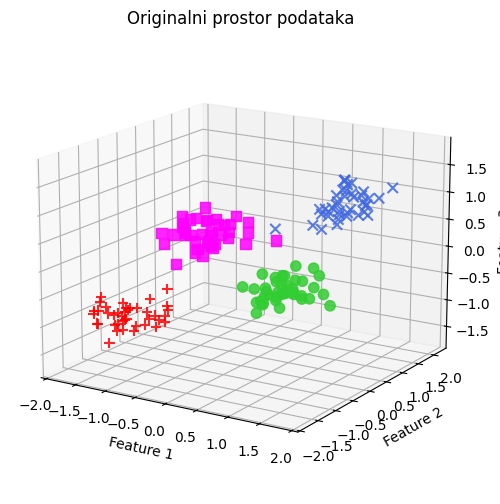

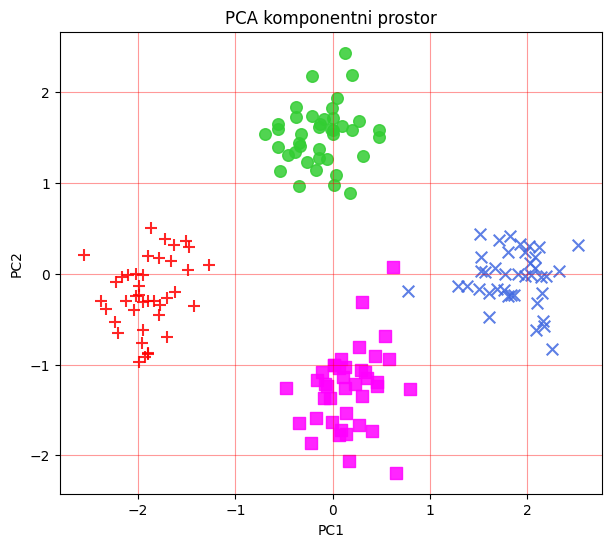

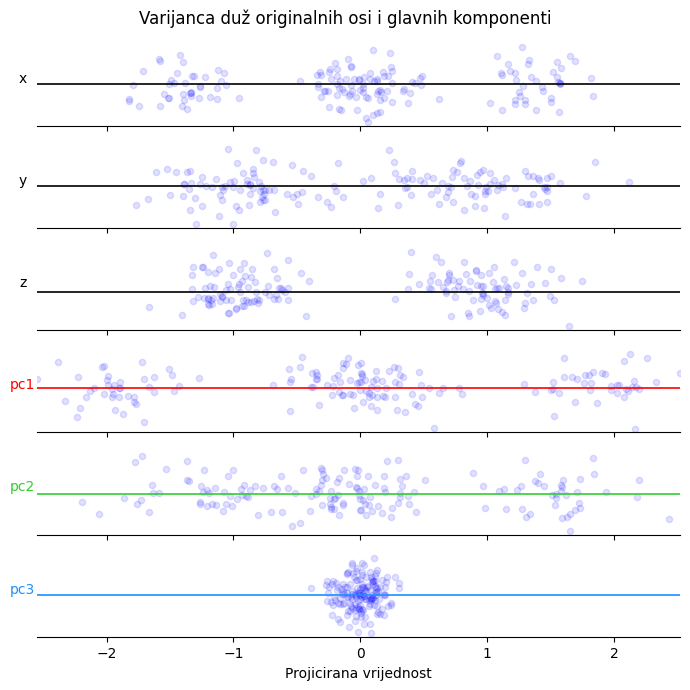

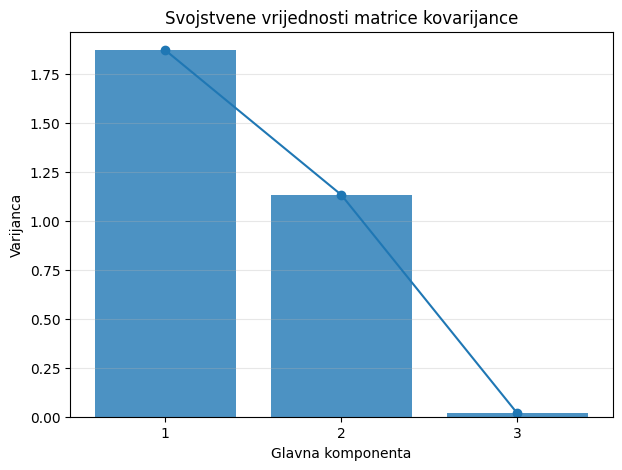

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# -------------------------------------------------
# Konstrukcija dataseta
# -------------------------------------------------
n = 40

centers = np.array([
    [-2.5, -0.5],
    [-0.5,  1.8],
    [ 0.8, -1.5],
    [ 2.8,  0.4]
])

X2 = []
y = []

for i, c in enumerate(centers):
    pts = np.random.normal(loc=c, scale=[0.45, 0.45], size=(n, 2))
    X2.append(pts)
    y.extend([i] * n)

X2 = np.vstack(X2)
y = np.array(y)

# Ugradnja 2D strukture u nagnutu 3D ravninu
u = np.array([1.0, 0.2, 0.9])
v = np.array([0.3, 1.0, -0.7])

u = u / np.linalg.norm(u)
v = v - np.dot(v, u) * u
v = v / np.linalg.norm(v)

w = np.cross(u, v)
w = w / np.linalg.norm(w)

X = np.outer(X2[:, 0], u) + np.outer(X2[:, 1], v)
X += np.random.normal(0, 0.18, size=(X.shape[0], 1)) * w

# -------------------------------------------------
# Standardizacija i PCA
# -------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print("Udio ukupne varijance:", pca3.explained_variance_ratio_)
print("Ukupno:", pca3.explained_variance_ratio_.sum())

# -------------------------------------------------
# Povezivanje s eigenvalues / eigenvectors
# -------------------------------------------------
cov_matrix = np.cov(X_scaled.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nMatrica kovarijance:")
print(cov_matrix)

print("\nSvojstvene vrijednosti (eigenvalues):")
print(eigenvalues)

print("\nSvojstveni vektori (stupci su eigenvectors):")
print(eigenvectors)

print("\nVarijanca duž svake PC:")
print(pca3.explained_variance_)

print("\nPCA komponente (redci su principal components):")
print(pca3.components_)

print("\nNapomena: PCA komponente i eigenvektori mogu se razlikovati u predznaku,")
print("ali predstavljaju iste smjerove.")


colors = ["red", "limegreen", "magenta", "royalblue"]
markers = ["+", "o", "s", "x"]

# Originalni 3D prostor
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(4):
    pts = X_scaled[y == i]
    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        c=colors[i], marker=markers[i], s=55, alpha=0.85
    )

ax.set_title("Originalni prostor podataka")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.view_init(elev=16, azim=-58)

plt.show()



# PCA komponentni prostor
plt.figure(figsize=(7, 6))

for i in range(4):
    pts = X_pca2[y == i]
    plt.scatter(
        pts[:, 0], pts[:, 1],
        c=colors[i], marker=markers[i], s=70, alpha=0.85
    )

plt.title("PCA komponentni prostor")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, color="red", alpha=0.4)

plt.show()


# Varijanca duž originalnih osi i PCA osi
labels = ["x", "y", "z", "pc1", "pc2", "pc3"]
data_list = [
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    X_pca3[:, 0],
    X_pca3[:, 1],
    X_pca3[:, 2]
]
axis_colors = ["black", "black", "black", "red", "limegreen", "dodgerblue"]

xmin = min(np.min(d) for d in data_list)
xmax = max(np.max(d) for d in data_list)

fig, axes = plt.subplots(6, 1, figsize=(7, 7), sharex=True)

for ax, data, label, c in zip(axes, data_list, labels, axis_colors):
    jitter = np.random.normal(0, 0.015, len(data))
    ax.scatter(data, jitter, alpha=0.12, color="blue", s=20)

    ax.axhline(0, color=c, linewidth=1.2)
    ax.set_xlim(xmin, xmax)

    ax.set_ylabel(label, rotation=0, labelpad=10, color=c)
    ax.set_yticks([])

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Projicirana vrijednost")

plt.suptitle("Varijanca duž originalnih osi i glavnih komponenti")
plt.tight_layout()
plt.show()


# Eigenvalues / explained variance
plt.figure(figsize=(7, 5))

pcs = np.arange(1, len(eigenvalues) + 1)
plt.bar(pcs, eigenvalues, alpha=0.8, label="Eigenvalues")
plt.plot(pcs, eigenvalues, marker="o")

plt.xlabel("Glavna komponenta")
plt.ylabel("Varijanca")
plt.title("Svojstvene vrijednosti matrice kovarijance")
plt.xticks(pcs)
plt.grid(axis="y", alpha=0.3)

plt.show()

**2. Iris dataset**

Udio ukupne varijance: [0.72962445 0.22850762 0.03668922 0.00517871]
Ukupno: 0.9999999999999999

Matrica kovarijance:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]

Svojstvene vrijednosti (eigenvalues):
[2.93808505 0.9201649  0.14774182 0.02085386]

Svojstveni vektori (stupci su eigenvectors):
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]

Varijanca duž svake PC:
[2.93808505 0.9201649  0.14774182 0.02085386]

PCA komponente (redci su principal components):
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]

Napomena: PCA k

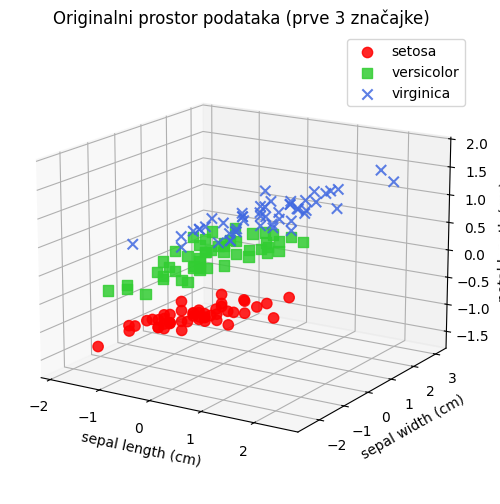

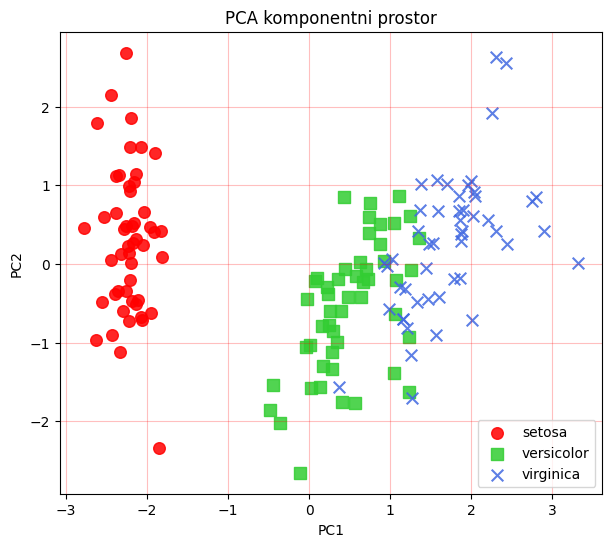

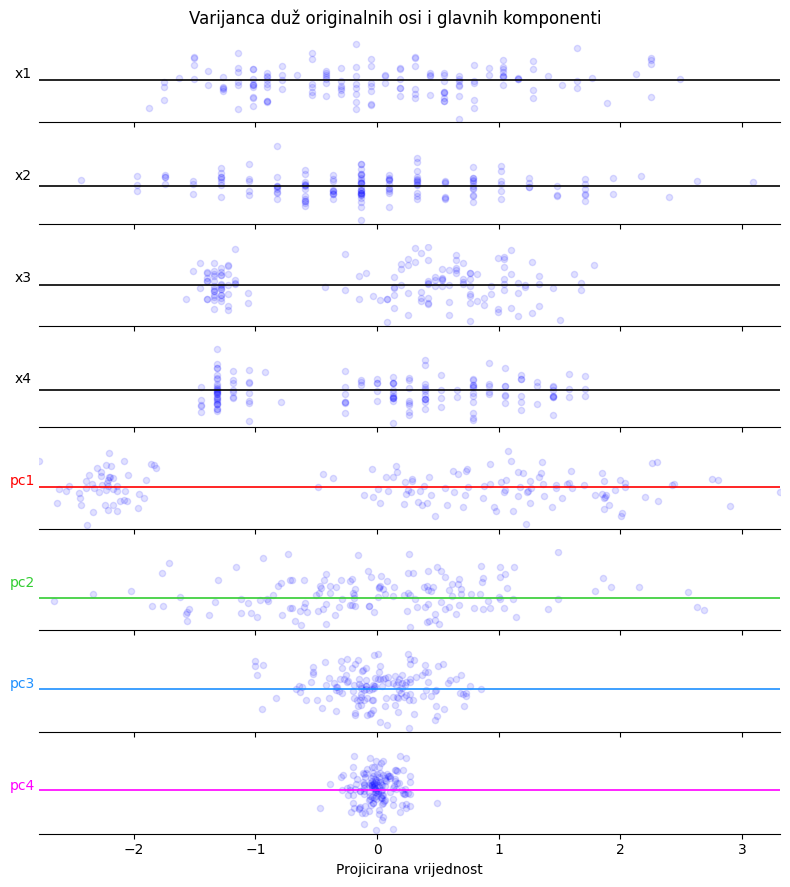

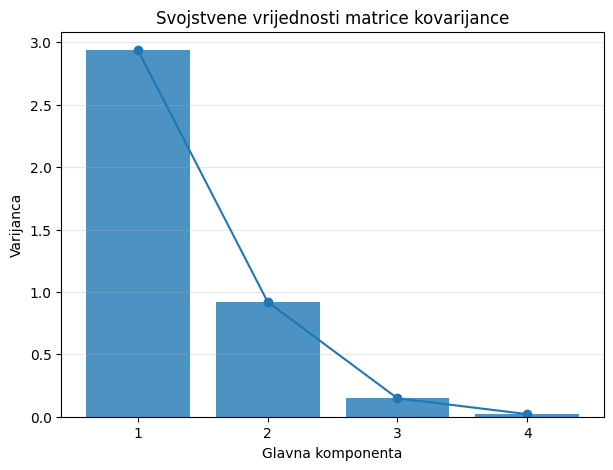

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# -------------------------------------------------
# Učitavanje Iris dataseta
# -------------------------------------------------
iris = load_iris()
X = iris.data          # shape = (150, 4)
y = iris.target        # 3 klase
feature_names = iris.feature_names
target_names = iris.target_names

# -------------------------------------------------
# Standardizacija i PCA
# -------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pca4 = PCA(n_components=4)
X_pca4 = pca4.fit_transform(X_scaled)

print("Udio ukupne varijance:", pca4.explained_variance_ratio_)
print("Ukupno:", pca4.explained_variance_ratio_.sum())

# -------------------------------------------------
# Povezivanje s eigenvalues / eigenvectors
# -------------------------------------------------
cov_matrix = np.cov(X_scaled.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nMatrica kovarijance:")
print(cov_matrix)

print("\nSvojstvene vrijednosti (eigenvalues):")
print(eigenvalues)

print("\nSvojstveni vektori (stupci su eigenvectors):")
print(eigenvectors)

print("\nVarijanca duž svake PC:")
print(pca4.explained_variance_)

print("\nPCA komponente (redci su principal components):")
print(pca4.components_)

print("\nNapomena: PCA komponente i eigenvektori mogu se razlikovati u predznaku,")
print("ali predstavljaju iste smjerove.")

# -------------------------------------------------
# Stil za klase
# -------------------------------------------------
colors = ["red", "limegreen", "royalblue"]
markers = ["o", "s", "x"]

# -------------------------------------------------
# Originalni prostor podataka (prve 3 značajke za 3D prikaz)
# -------------------------------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

for i in range(3):
    pts = X_scaled[y == i]
    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        c=colors[i], marker=markers[i], s=55, alpha=0.85,
        label=target_names[i]
    )

ax.set_title("Originalni prostor podataka (prve 3 značajke)")
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])
ax.view_init(elev=16, azim=-58)
ax.legend()

plt.show()

# -------------------------------------------------
# PCA komponentni prostor
# -------------------------------------------------
plt.figure(figsize=(7, 6))

for i in range(3):
    pts = X_pca2[y == i]
    plt.scatter(
        pts[:, 0], pts[:, 1],
        c=colors[i], marker=markers[i], s=70, alpha=0.85,
        label=target_names[i]
    )

plt.title("PCA komponentni prostor")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, color="red", alpha=0.25)

plt.show()

# -------------------------------------------------
# Varijanca duž originalnih osi i PCA osi
# -------------------------------------------------
labels = ["x1", "x2", "x3", "x4", "pc1", "pc2", "pc3", "pc4"]
data_list = [
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    X_scaled[:, 3],
    X_pca4[:, 0],
    X_pca4[:, 1],
    X_pca4[:, 2],
    X_pca4[:, 3]
]
axis_colors = [
    "black", "black", "black", "black",
    "red", "limegreen", "dodgerblue", "magenta"
]

xmin = min(np.min(d) for d in data_list)
xmax = max(np.max(d) for d in data_list)

fig, axes = plt.subplots(len(data_list), 1, figsize=(8, 9), sharex=True)

for ax, data, label, c in zip(axes, data_list, labels, axis_colors):
    jitter = np.random.normal(0, 0.015, len(data))
    ax.scatter(data, jitter, alpha=0.12, color="blue", s=20)

    ax.axhline(0, color=c, linewidth=1.2)
    ax.set_xlim(xmin, xmax)

    ax.set_ylabel(label, rotation=0, labelpad=12, color=c)
    ax.set_yticks([])

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Projicirana vrijednost")

plt.suptitle("Varijanca duž originalnih osi i glavnih komponenti")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Eigenvalues / explained variance
# -------------------------------------------------
plt.figure(figsize=(7, 5))

pcs = np.arange(1, len(eigenvalues) + 1)
plt.bar(pcs, eigenvalues, alpha=0.8, label="Eigenvalues")
plt.plot(pcs, eigenvalues, marker="o")

plt.xlabel("Glavna komponenta")
plt.ylabel("Varijanca")
plt.title("Svojstvene vrijednosti matrice kovarijance")
plt.xticks(pcs)
plt.grid(axis="y", alpha=0.3)

plt.show()